In [1]:
import os
HEADLESS = False
if HEADLESS:
    os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
    os.environ.setdefault("SDL_AUDIODRIVER", "dummy")
import gymnasium as gym
import highway_env
import math
import random
import time
import statistics as stats
import base64
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from shared_core_config import SHARED_CORE_CONFIG, SHARED_CORE_ENV_ID

In [2]:
# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

In [3]:
# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [4]:
def make_env(seed, render=False):
    config = dict(SHARED_CORE_CONFIG)
    render_mode = None
    if render:
        config["offscreen_rendering"] = HEADLESS
        render_mode = "rgb_array"
    env = gym.make(SHARED_CORE_ENV_ID, config=config, render_mode=render_mode)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

In [5]:
seed = 7
env = make_env(seed=seed, render=True)
env.reset(seed=seed)
env.action_space.seed(seed)
env.observation_space.seed(seed)

7

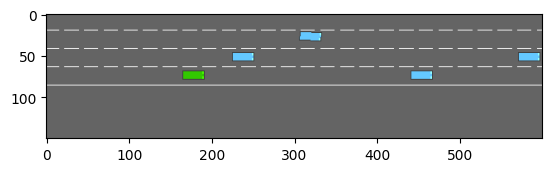

(array([[ 1.        ,  0.9154936 ,  0.75      ,  0.3125    ,  0.        ],
        [ 1.        ,  0.10124674, -0.25      , -0.02091179,  0.        ],
        [ 1.        ,  0.20780484, -0.5       , -0.04980255,  0.        ],
        [ 1.        ,  0.30802953,  0.        , -0.03245244,  0.        ],
        [ 1.        ,  0.41225109, -0.25      , -0.03330964,  0.        ],
        [ 1.        ,  0.52777356, -0.5       , -0.01266874,  0.        ],
        [ 1.        ,  0.62287587, -0.5       , -0.04192592,  0.        ],
        [ 1.        ,  0.71402246,  0.        , -0.04835217,  0.        ],
        [ 1.        ,  0.8252466 ,  0.        , -0.01560621,  0.        ],
        [ 1.        ,  0.9245628 , -0.5       , -0.03136725,  0.        ]],
       dtype=float32),
 {'speed': 25.0,
  'crashed': False,
  'action': np.int64(0),
  'rewards': {'collision_reward': 0.0,
   'right_lane_reward': 1.0,
   'high_speed_reward': np.float64(0.375),
   'on_road_reward': 1.0}})

In [6]:
for _ in range(3):
    action = env.unwrapped.action_type.actions_indexes["IDLE"]
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()

plt.imshow(frame)
plt.show()
env.reset(seed=seed)

## DQN

### Replay Memory

**Replay memory** stores the transitions that the agent observes, allowing us to reuse this data later. By sampling from it randomly, the transitions that build up a batch are decorrelated. It has been shown that this greatly stabilizes and improves the DQN training procedure.

In [7]:
# Transition : single transition in our env, maps (state,action) to (nex_state, reward)
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

# Replay memory : cyclic buffer of bounded size that holds transitions observed recently
class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size): # selecting a random batch of transitions for training
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

### DQN algorithm

In [10]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions, hidden_size=256):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.layer3 = nn.Linear(hidden_size, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization.
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

### Training - utilities & hyperparameters

In [11]:
# hyperparameters
BATCH_SIZE = 32             # the number of transitions sampled from the replay buffer
GAMMA = 0.8                 # the discount factor
EPS_START = 1.0             # the starting value of epsilon
EPS_END = 0.05              # the final value of epsilon
EPS_DECAY = 5000            # exponential decay of epsilon : higher means a slower decay
TARGET_UPDATE_EVERY = 50    # the hard update interval for the target network
LR = 5e-4                   # the learning rate of the ``AdamW`` optimizer
LEARNING_STARTS = 200
REPLAY_CAPACITY = 15000

In [12]:
# Training/evaluation settings
if torch.cuda.is_available() or torch.backends.mps.is_available():
    NUM_EPISODES = 2e4
else:
    NUM_EPISODES = 2e3

EVAL_EPISODES = 25
SEEDS = [0, 1, 2, 3, 4, 5]
CHECKPOINT_EVERY = 100
BEST_AVG_WINDOW = 20

In [14]:
# utilities
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def save_checkpoint(path, policy_net, target_net, optimizer, steps_done, episode, seed, episode_rewards):
    torch.save(
        {
            "policy_state_dict": policy_net.state_dict(),
            "target_state_dict": target_net.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "steps_done": steps_done,
            "episode": episode,
            "seed": seed,
            "episode_rewards": episode_rewards,
        },
        path,
    )

def to_state_tensor(obs):
    return torch.tensor(obs, dtype=torch.float32, device=device).view(1, -1)

In [15]:
# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
n_observations = int(torch.tensor(state).numel())

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(REPLAY_CAPACITY)

In [16]:
steps_done = 0
def select_action(state, epsilon=None):
    global steps_done
    sample = random.random()
    if epsilon is None:
        eps_threshold = EPS_END + (EPS_START - EPS_END) * \
            math.exp(-1. * steps_done / EPS_DECAY)
        steps_done += 1
    else:
        eps_threshold = epsilon
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

In [17]:
episode_rewards = []
def plot_training(rewards, show_result=False):
    plt.figure(1)
    rewards_t = torch.tensor(rewards, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.plot(rewards_t.numpy())
    # Take 100 episode averages and plot them too
    if len(rewards_t) >= 100:
        means = rewards_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())


def evaluate_policy(eval_env, policy_net, n_episodes, seed_offset):
    policy_net.eval()
    rewards = []
    lengths = []
    with torch.no_grad():
        for i in range(n_episodes):
            state, _ = eval_env.reset(seed=seed_offset + i)
            state = to_state_tensor(state)
            total_reward = 0.0
            for t in count():
                action = policy_net(state).max(1).indices.view(1, 1)
                obs, reward, terminated, truncated, _ = eval_env.step(action.item())
                total_reward += reward
                done = terminated or truncated
                if done:
                    rewards.append(total_reward)
                    lengths.append(t + 1)
                    break
                state = to_state_tensor(obs)
    policy_net.train()
    return stats.mean(rewards), stats.mean(lengths)

### Training loop

In [19]:
def optimize_model(): # signle step of the optimization
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = [s for s in batch.next_state if s is not None]
    if len(non_final_next_states) > 0:
        non_final_next_states = torch.cat(non_final_next_states)
    else:
        non_final_next_states = torch.empty((0, n_observations), device=device)
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        if non_final_next_states.numel() > 0:
            next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

In [20]:
RUN_ID = time.strftime("%Y%m%d-%H%M%S")
CHECKPOINT_DIR = os.path.join("checkpoints", f"run_{RUN_ID}")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
results = []
all_seed_rewards = []
all_seed_lengths = []

for run_seed in SEEDS:
    set_seed(run_seed)
    env = make_env(run_seed)

    policy_net = DQN(n_observations, n_actions).to(device)
    target_net = DQN(n_observations, n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())

    optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
    memory = ReplayMemory(REPLAY_CAPACITY)
    steps_done = 0

    episode_rewards = []
    episode_lengths = []
    best_avg_reward = float('-inf')

    for i_episode in range(NUM_EPISODES):
        state, info = env.reset(seed=run_seed + i_episode)
        state = to_state_tensor(state)
        total_reward = 0.0
        for t in count():
            action = select_action(state)
            observation, reward, terminated, truncated, _ = env.step(action.item())
            total_reward += reward
            reward = torch.tensor([reward], device=device)
            done = terminated or truncated

            if done:
                next_state = None
            else:
                next_state = to_state_tensor(observation)

            # Store the transition in memory
            memory.push(state, action, next_state, reward)

            # Move to the next state
            state = next_state

            # Perform one step of the optimization (on the policy network)
            if len(memory) >= max(BATCH_SIZE, LEARNING_STARTS):
                optimize_model()

            # Hard update of the target network
            if steps_done % TARGET_UPDATE_EVERY == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                episode_rewards.append(total_reward)
                episode_lengths.append(t + 1)
                plot_training(episode_rewards)
                break

        if (i_episode + 1) % CHECKPOINT_EVERY == 0:
            ckpt_path = os.path.join(CHECKPOINT_DIR, f"seed{run_seed}_ep{i_episode + 1}.pt")
            save_checkpoint(ckpt_path, policy_net, target_net, optimizer, steps_done, i_episode + 1, run_seed, episode_rewards)

        if len(episode_rewards) >= BEST_AVG_WINDOW:
            window_avg = stats.mean(episode_rewards[-BEST_AVG_WINDOW:])
            if window_avg > best_avg_reward:
                best_avg_reward = window_avg
                best_path = os.path.join(CHECKPOINT_DIR, f"seed{run_seed}_best.pt")
                save_checkpoint(best_path, policy_net, target_net, optimizer, steps_done, i_episode + 1, run_seed, episode_rewards)

    eval_env = make_env(run_seed + 1000)
    avg_eval_reward, avg_eval_length = evaluate_policy(eval_env, policy_net, EVAL_EPISODES, run_seed + 2000)
    eval_env.close()
    env.close()

    results.append({
        "seed": run_seed,
        "avg_eval_reward": avg_eval_reward,
        "avg_eval_length": avg_eval_length,
    })
    all_seed_rewards.append(episode_rewards)
    all_seed_lengths.append(episode_lengths)

print('Training complete')
plot_training(episode_rewards, show_result=True)
plt.ioff()
plt.show()

# Aggregate training curve across seeds
if len(all_seed_rewards) > 0:
    max_len = min(len(r) for r in all_seed_rewards)
    mean_rewards = []
    std_rewards = []
    for i in range(max_len):
        per_seed = [r[i] for r in all_seed_rewards]
        mean_rewards.append(stats.mean(per_seed))
        std_rewards.append(stats.pstdev(per_seed) if len(per_seed) > 1 else 0.0)

    plt.figure(2)
    plt.title('Mean training reward across seeds')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    episodes = list(range(1, max_len + 1))
    plt.plot(episodes, mean_rewards, label='mean')
    lower = [m - s for m, s in zip(mean_rewards, std_rewards)]
    upper = [m + s for m, s in zip(mean_rewards, std_rewards)]
    plt.fill_between(episodes, lower, upper, alpha=0.2, label='std')
    plt.legend()
    plt.show()

# Evaluation table
print('| seed | avg_eval_reward | avg_eval_length |')
print('| --- | --- | --- |')
for row in results:
    print(f"| {row['seed']} | {row['avg_eval_reward']:.2f} | {row['avg_eval_length']:.2f} |")

### Evaluation

In [ ]:
def _lane_change_actions(env):
    idxs = set()
    try:
        actions = env.unwrapped.action_type.actions_indexes
        for name, idx in actions.items():
            if "LANE" in name:
                idxs.add(idx)
    except Exception:
        return idxs
    return idxs


def evaluate_policy_metrics(policy_net, seeds, n_episodes=10):
    rows = []
    for seed in seeds:
        eval_env = make_env(seed, render=False)
        lane_change_idxs = _lane_change_actions(eval_env)
        rewards = []
        lengths = []
        crashes = []
        lane_changes = []
        mean_speeds = []

        policy_net.eval()
        with torch.no_grad():
            for ep in range(n_episodes):
                obs, info = eval_env.reset(seed=seed + ep)
                state = to_state_tensor(obs)
                done = False
                total_reward = 0.0
                steps = 0
                crashed = False
                lane_change_count = 0
                speeds = []
                while not done:
                    action = policy_net(state).max(1).indices.view(1, 1)
                    action_idx = int(action.item())
                    if action_idx in lane_change_idxs:
                        lane_change_count += 1
                    obs, reward, terminated, truncated, info = eval_env.step(action_idx)
                    total_reward += reward
                    steps += 1
                    if isinstance(info, dict):
                        if "speed" in info:
                            speeds.append(info["speed"])
                        if info.get("crashed"):
                            crashed = True
                    done = terminated or truncated
                    if not done:
                        state = to_state_tensor(obs)
                rewards.append(total_reward)
                lengths.append(steps)
                crashes.append(1 if crashed else 0)
                lane_changes.append(lane_change_count)
                mean_speeds.append(stats.mean(speeds) if speeds else 0.0)
        policy_net.train()
        eval_env.close()

        rows.append({
            "seed": seed,
            "reward_mean": stats.mean(rewards),
            "reward_std": stats.pstdev(rewards) if len(rewards) > 1 else 0.0,
            "length_mean": stats.mean(lengths),
            "crash_rate": stats.mean(crashes),
            "lane_changes_mean": stats.mean(lane_changes),
            "speed_mean": stats.mean(mean_speeds),
        })
    return rows


def print_eval_table(rows):
    print("| seed | reward_mean | reward_std | length_mean | crash_rate | lane_changes_mean | speed_mean |")
    print("| --- | --- | --- | --- | --- | --- | --- |")
    for row in rows:
        print(
            f"| {row['seed']} | {row['reward_mean']:.2f} | {row['reward_std']:.2f} | "
            f"{row['length_mean']:.2f} | {row['crash_rate']:.2f} | "
            f"{row['lane_changes_mean']:.2f} | {row['speed_mean']:.2f} |"
        )

In [ ]:
# Load a checkpoint, evaluate, and record videos
CHECKPOINT_DIR = 'checkpoints/run_20260317-201128'
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "seed0_best.pt")

ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
policy_net = DQN(n_observations, n_actions).to(device)
policy_net.load_state_dict(ckpt["policy_state_dict"])
eval_rows = evaluate_policy_metrics(policy_net, SEEDS, n_episodes=EVAL_EPISODES)
print_eval_table(eval_rows)